Part1: Imports and Device Setup

In [1]:
# -*- coding: UTF-8 -*-

import os
import json
import numpy as np
import torch

from utils import wind_data, load_data, pv_data
from utils_quality import quantiles_and_evaluation
from utils_models import scale_data_multi, plot_loss
from utils_NFs import fit_NF, build_nfs_scenarios
from utils import dump_file
from numpyencoder import NumpyEncoder
from torch.utils.benchmark import timer

from models import *

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print('Using gpu: %s ' % torch.cuda.is_available())

Using gpu: False 


Part2: Global Settings

In [2]:
# ------------------------------------------------------------------------------------------------------------------
# GEFcom IJF_paper case study configuration
# ------------------------------------------------------------------------------------------------------------------

tag = 'pv'  # pv, wind, load
gpu = True  # put False to use CPU
print('Using gpu: %s ' % torch.cuda.is_available())
if gpu:
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

dir_path = 'export/multi_nfs_' + tag + '/'
if not os.path.isdir(dir_path):  # test if directory exist
    os.makedirs(dir_path)


Using gpu: False 


Part3: Load Data

In [3]:
# ------------------------------------------------------------------------------------------------------------------
# Load LS, VS, TEST sets
# ------------------------------------------------------------------------------------------------------------------
if tag == 'pv':
    # WARNING: the time periods where PV is always 0 (night hours) are removed -> there are 8 periods removed
    # The index of the time periods removed are provided into indices
    # data, indices = pv_data(path_name='../data/solar.csv')
    data, indices = pv_data(path_name='solar_new.csv', test_size=50, random_state=0)
    ylim_loss = [-50, 50]
    ymax_plf = 2
    ylim_crps = [0, 10]
    nb_zones = 3

elif tag == 'wind':
    # data = wind_data(path_name='../data/wind.csv', random_state=0)
    data = wind_data(path_name='GEFcom2014/data/wind_data_all_zone.csv', test_size=50, random_state=0)
    ylim_loss = [0, 40]
    ymax_plf = 8
    ylim_crps = [6, 12]
    nb_zones = 10
    indices = []

elif tag == 'load':
    # data = load_data(path_name='../data/load.csv', random_state=0)
    data = load_data(path_name='GEFcom2014/data/load_data_track1.csv', test_size=50, random_state=0)
    ylim_loss = [-20, 50]
    ymax_plf = 2
    ylim_crps = [0, 4]
    nb_zones = 1
    indices = []


df_x_LS = data[0].copy()
df_y_LS = data[1].copy()
df_x_VS = data[2].copy()
df_y_VS = data[3].copy()
df_x_TEST = data[4].copy()
df_y_TEST = data[5].copy()

nb_days_LS = len(df_y_LS)
nb_days_VS = len(df_y_VS)
nb_days_TEST = len(df_y_TEST)
print('#LS %s days #VS %s days # TEST %s days' % (nb_days_LS/nb_zones, nb_days_VS/nb_zones, nb_days_TEST/nb_zones))



zone 1 [ 0  1  2  3 20 21 22 23]
zone 2 [ 0  1  2  3 20 21 22 23]
zone 3 [ 0  1  2  3 20 21 22 23]
ZONE_1 #LS 720 days #VS 50 days # TEST 50 days
ZONE_2 #LS 720 days #VS 50 days # TEST 50 days
ZONE_3 #LS 720 days #VS 50 days # TEST 50 days
#LS 720.0 days #VS 50.0 days # TEST 50.0 days


Part4: Scaling Data

In [4]:
# ------------------------------------------------------------------------------------------------------------------
# Scale datasets
# ------------------------------------------------------------------------------------------------------------------

x_LS_scaled, y_LS_scaled, x_VS_scaled, y_VS_scaled, x_TEST_scaled, y_TEST_scaled, y_LS_scaler = scale_data_multi(x_LS=df_x_LS.values, y_LS=df_y_LS.values, x_VS=df_x_VS.values, y_VS=df_y_VS.values, x_TEST=df_x_TEST.values, y_TEST=df_y_TEST.values)

non_null_indexes = list(np.delete(np.asarray([i for i in range(24)]), indices))

if tag == 'pv':
    # Rebuilt the PV observations with the removed time periods
    df_y_TEST.columns = non_null_indexes
    for i in indices:
        df_y_TEST[i] = 0
    df_y_TEST = df_y_TEST.sort_index(axis=1)

    df_y_VS.columns = non_null_indexes
    for i in indices:
        df_y_VS[i] = 0
    df_y_VS = df_y_VS.sort_index(axis=1)


Part5: Define NF Model Hyperparameters

In [5]:
# ------------------------------------------------------------------------------------------------------------------
# NF Hyperparameters
# ------------------------------------------------------------------------------------------------------------------
n_s = 100
N_q = 99

# Define the NFs hyper-parameters
if tag == 'pv':
    nb_epoch = 500
    cf_UMNN_M = {
        'name': 'UMNN_M_3',
        'nb_steps': 1,
        'nb_layers': 4,
        'nb_neurons': 300,
        'out_size': 20,
        'weight_decay': 5e-4,
        'learning_rate': 5e-4,
        'conditioner_type': 'AutoregressiveConditioner',
        'normalizer_type': 'MonotonicNormalizer',
    }

    cf_AN_M = {
        'name': 'AN_M_10',
        'nb_steps': 4,
        'nb_layers': 4,
        'nb_neurons': 500,
        'out_size': 2,
        'weight_decay': 1e-2,
        'learning_rate': 1e-4,
        'conditioner_type': 'AutoregressiveConditioner',
        'normalizer_type': 'AffineNormalizer',
    }

elif tag == 'wind':
    nb_epoch = 600
    cf_UMNN_M = {
        'name': 'UMNN_M_1',
        'nb_steps': 1,
        'nb_layers': 4,
        'nb_neurons': 300,
        'out_size': 20,
        'weight_decay': 5e-4,
        'learning_rate': 1e-4,
        'conditioner_type': 'AutoregressiveConditioner',
        'normalizer_type': 'MonotonicNormalizer',
    }

    cf_AN_M = {
        'name': 'AN_M_8',
        'nb_steps': 4,
        'nb_layers': 4,
        'nb_neurons': 300,
        'out_size': 2,
        'weight_decay': 1e-3,
        'learning_rate': 1e-4,
        'conditioner_type': 'AutoregressiveConditioner',
        'normalizer_type': 'AffineNormalizer',
    }

elif tag == 'load':
    nb_epoch = 500
    cf_UMNN_M = {
        'name': 'UMNN_M_1',
        'nb_steps': 1,
        'nb_layers': 4,
        'nb_neurons': 300,
        'out_size': 20,
        'weight_decay': 5e-4,
        'learning_rate': 1e-4,
        'conditioner_type': 'AutoregressiveConditioner',
        'normalizer_type': 'MonotonicNormalizer',
    }

    cf_AN_M = {
        'name': 'AN_M_1',
        'nb_steps': 5,
        'nb_layers': 5,
        'nb_neurons': 300,
        'out_size': 2,
        'weight_decay': 1e-3,
        'learning_rate': 1e-4,
        'conditioner_type': 'AutoregressiveConditioner',
        'normalizer_type': 'AffineNormalizer',
    }


print('UMNN-M nb_steps %s nb_layers %s nb_neurons %s out_size %s weight_decay %.4e lr %.4e' % (cf_UMNN_M['nb_steps'], cf_UMNN_M['nb_layers'], cf_UMNN_M['nb_neurons'], cf_UMNN_M['out_size'], cf_UMNN_M['weight_decay'], cf_UMNN_M['learning_rate']))
print('AN-M   nb_steps %s nb_layers %s nb_neurons %s out_size %s weight_decay %.4e lr %.4e' % (cf_AN_M['nb_steps'], cf_AN_M['nb_layers'], cf_AN_M['nb_neurons'], cf_AN_M['out_size'], cf_AN_M['weight_decay'], cf_AN_M['learning_rate']))

# Set the torch seed for result reproducibility
torch_seed = 0
torch.manual_seed(torch_seed)

UMNN-M nb_steps 1 nb_layers 4 nb_neurons 300 out_size 20 weight_decay 5.0000e-04 lr 5.0000e-04
AN-M   nb_steps 4 nb_layers 4 nb_neurons 500 out_size 2 weight_decay 1.0000e-02 lr 1.0000e-04


Part6: Training Loop, Scenario generation + evaluation

pv_AN_M_10_0
Fit NFs with 500 epochs
Fitting time_tot 2 mintime left : 0.028292 min - LS loss: -15.007396 VS loss: -9.545044 TEST loss: -10.923784
Training time 94.32 s
epoch 485 ll VS is min = -10.40 ll TEST = -11.01


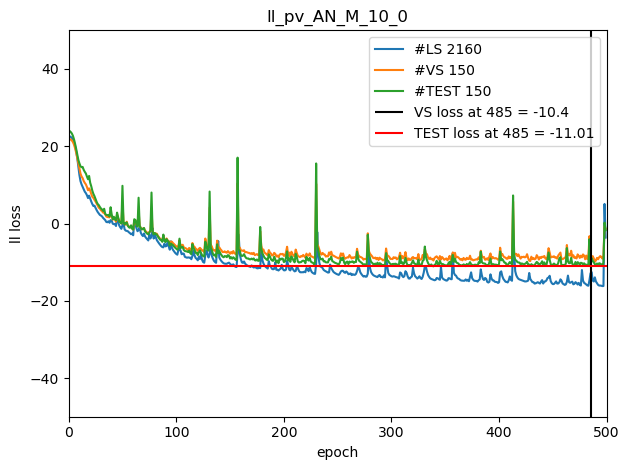

4 4
Scenario generation time_tot 0.1 min0000 min
4 4
Scenario generation time_tot 0.1 min0000 min
Generation time (LS, VS, TEST) 6.38 s
PLF TEST 1.2832 VS 1.3172



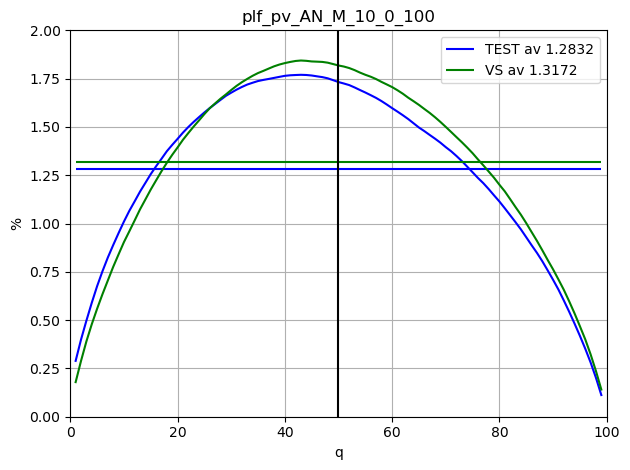

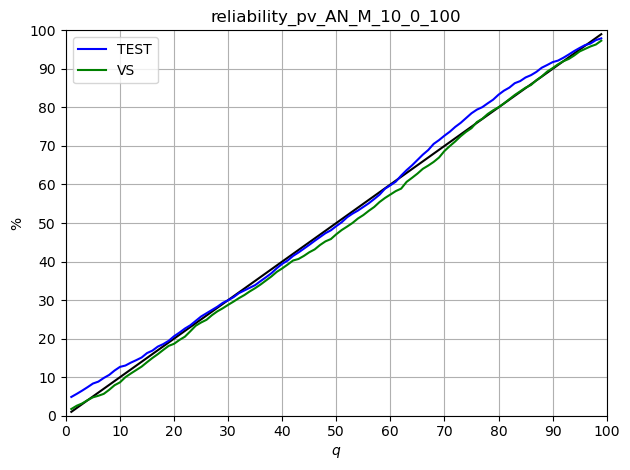

MAE TEST 1.47 VS 1.35
RMSE TEST 1.84 VS 1.64



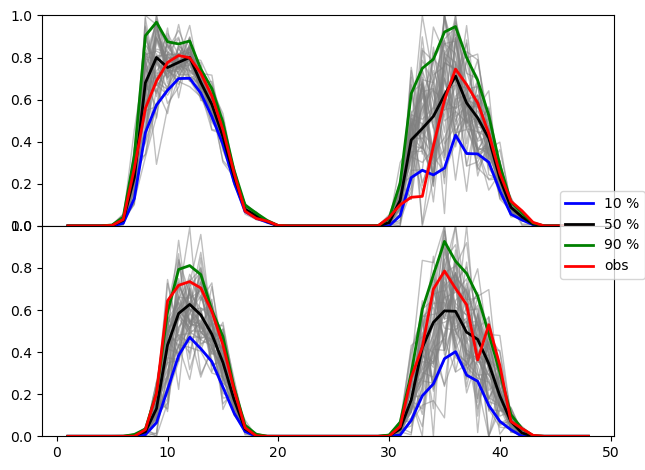

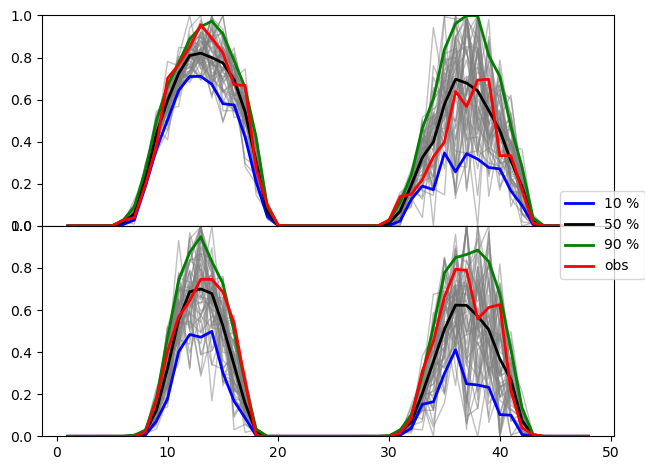

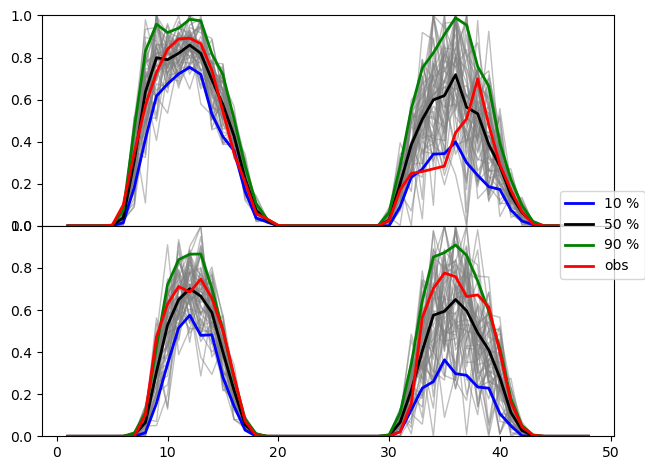

CRPS TEST 2.54 VS 2.61



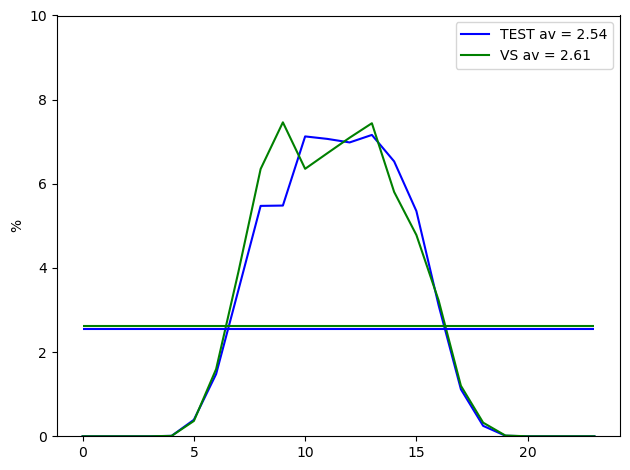

pv_UMNN_M_3_0
Fit NFs with 500 epochs
Fitting time_tot 15 minime left : 0.274723 min - LS loss: -15.735239 VS loss: -4.987131 TEST loss: -8.9735435
Training time 915.70 s
epoch 319 ll VS is min = -8.73 ll TEST = -10.55


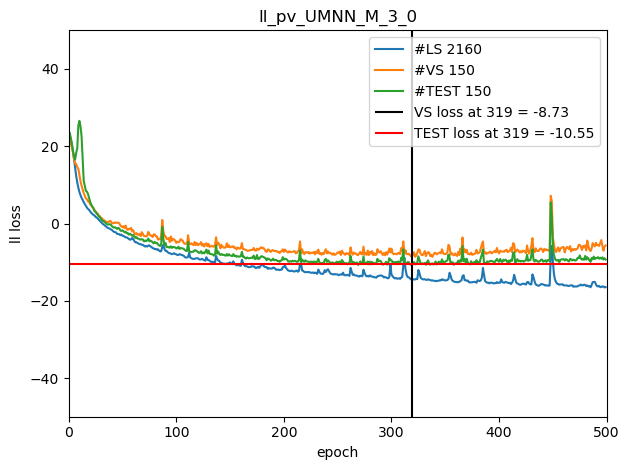

4 4
Scenario generation time_tot 2.4 min0000 min
4 4
Scenario generation time_tot 2.4 min0000 min
Generation time (LS, VS, TEST) 285.09 s
PLF TEST 1.2410 VS 1.3932



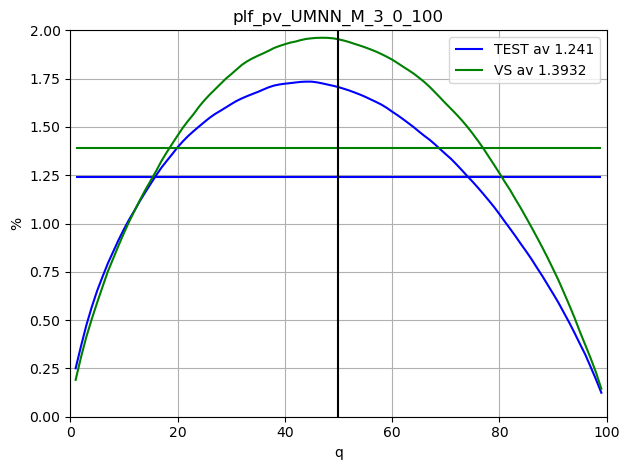

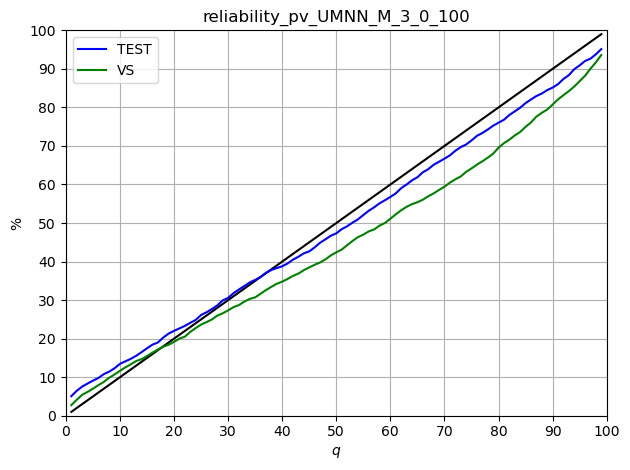

MAE TEST 2.78 VS 6.12
RMSE TEST 3.06 VS 7.11



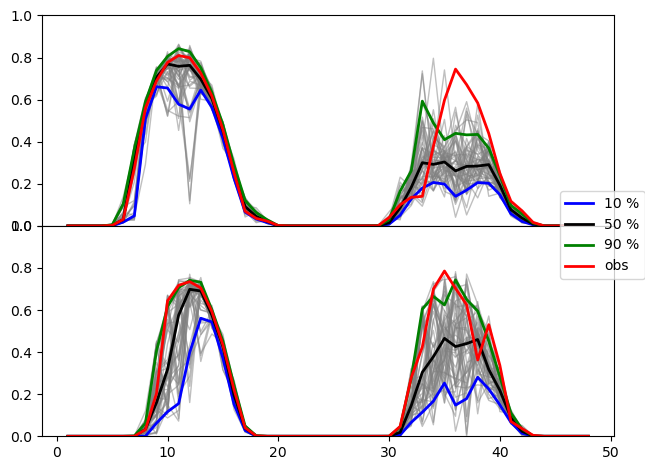

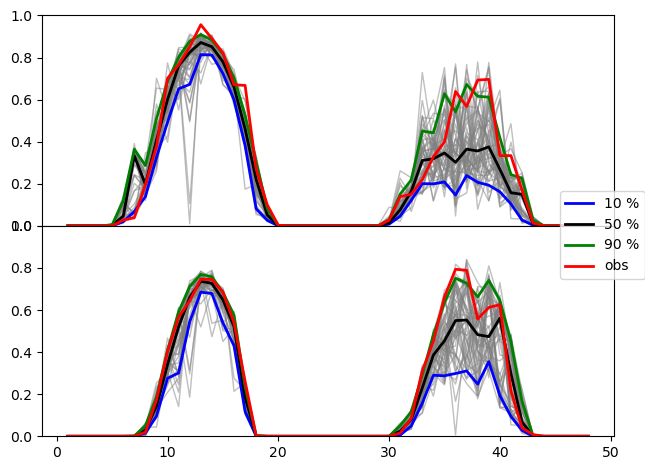

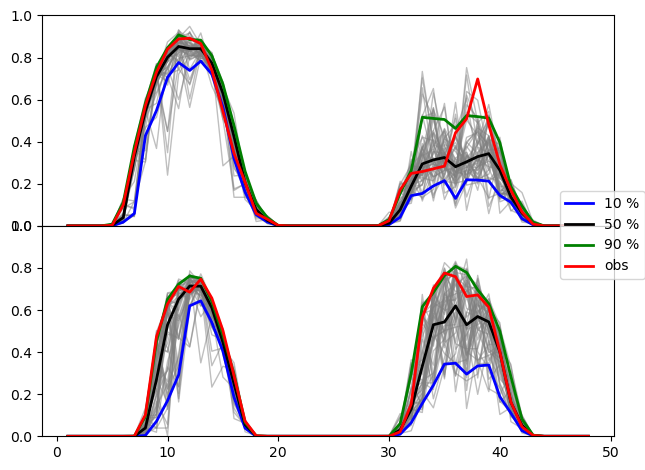

CRPS TEST 2.46 VS 2.76



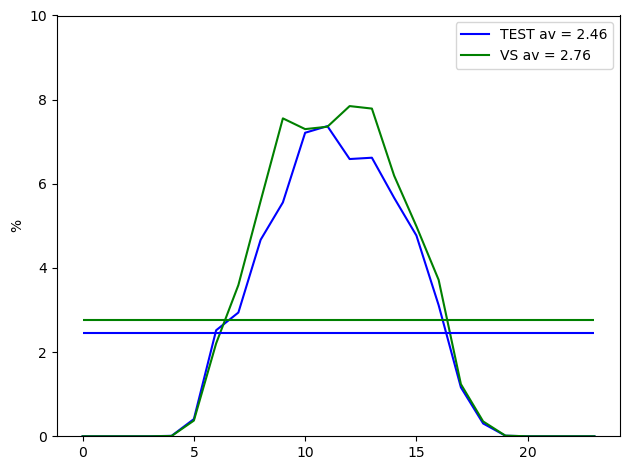

In [6]:
# ------------------------------------------------------------------------------------------------------------------
# Train AN-M & UMNN-M models
# ------------------------------------------------------------------------------------------------------------------

for config in [cf_AN_M, cf_UMNN_M]:
    # --------------------------------------------------------------------------------------------------------------
    # Build the NFs
    # --------------------------------------------------------------------------------------------------------------
    name = tag + '_' + config['name'] + '_' + str(torch_seed)
    print(name)

    if config['normalizer_type'] == 'AffineNormalizer':
        config['conditioner_args'] = {"in_size": y_LS_scaled.shape[1],
                                      "hidden": [config['nb_neurons']] * config['nb_layers'], "out_size": 2,
                                      "cond_in": x_LS_scaled.shape[1]}
        normalizer_type = AffineNormalizer
        config['normalizer_args'] = {}

    elif config['normalizer_type'] == 'MonotonicNormalizer':
        config['conditioner_args'] = {"in_size": y_LS_scaled.shape[1],
                                      "hidden": [config['nb_neurons']] * config['nb_layers'],
                                      "out_size": config['out_size'], "cond_in": x_LS_scaled.shape[1]}
        normalizer_type = MonotonicNormalizer
        config['normalizer_args'] = {
            'integrand_net': [config['out_size'] * 2, config['out_size'] * 2, config['out_size'] * 2],
            'cond_size': config['out_size'], 'nb_steps': 50, 'solver': "CCParallel", 'hot_encoding': True}

    config['Adam_args'] = {"lr": config['learning_rate'], "weight_decay": config['weight_decay']}

    with open(dir_path + config['name'] + '.json', 'w') as file:
        json.dump(config, file, cls=NumpyEncoder)

    nfs = buildFCNormalizingFlow(nb_steps=config['nb_steps'], conditioner_type=AutoregressiveConditioner,
                                 conditioner_args=config['conditioner_args'], normalizer_type=normalizer_type,
                                 normalizer_args=config['normalizer_args'])
    opt = torch.optim.Adam(nfs.parameters(), lr=config['learning_rate'], weight_decay=config['weight_decay'])

    # --------------------------------------------------------------------------------------------------------------
    # Fit the NFs
    # --------------------------------------------------------------------------------------------------------------
    print('Fit NFs with %s epochs' % (nb_epoch))
    training_time = 0.
    start = timer()
    loss, best_flow, last_flow = fit_NF(nb_epoch=nb_epoch, x_LS=x_LS_scaled, y_LS=y_LS_scaled, x_VS=x_VS_scaled,
                                        y_VS=y_VS_scaled, x_TEST=x_TEST_scaled, y_TEST=y_TEST_scaled,
                                        flow=nfs,
                                        opt=opt, gpu=gpu)

    end = timer()
    training_time += end - start
    print('Training time %.2f s' % (training_time))
    epoch_min = np.nanargmin(loss[:, 1])
    print('epoch %s ll VS is min = %.2f ll TEST = %.2f' % (epoch_min, loss[epoch_min, 1], loss[epoch_min, 2]))

    dump_file(dir=dir_path, name='loss_' + name, file=loss)
    dump_file(dir=dir_path, name=name, file=best_flow)

    # --------------------------------------------------------------------------------------------------------------
    # Plot loss function
    # --------------------------------------------------------------------------------------------------------------
    plot_loss(loss=loss, nb_days=[nb_days_LS, nb_days_VS, nb_days_TEST], ylim=ylim_loss, dir_path=dir_path, name='ll_' + name)
# ------------------------------------------------------------------------------------------------------------------
# Generate scenarios (VS & TEST)
# ------------------------------------------------------------------------------------------------------------------
   # --------------------------------------------------------------------------------------------------------------
    # Build scenarios on VS & TEST
    # --------------------------------------------------------------------------------------------------------------
    # best_flow = read_file(dir=dir_path, name=name)
    max_power = 1
    # Scenarios are generated into a dict of length nb days (#VS or # TEST sizes)
    # Each day of the dict is an array of shape (n_scenarios, 24)
    generation_time = 0.
    start = timer()
    s_TEST = build_nfs_scenarios(n_s=n_s, x=x_TEST_scaled,
                                 y_scaler=y_LS_scaler, flow=best_flow,
                                 conditioner_args=config['conditioner_args'], max=max_power, gpu=gpu, tag=tag, non_null_indexes=non_null_indexes)
    s_VS = build_nfs_scenarios(n_s=n_s, x=x_VS_scaled,
                                y_scaler=y_LS_scaler, flow=best_flow,
                                conditioner_args=config['conditioner_args'], max=max_power, gpu=gpu, tag=tag, non_null_indexes=non_null_indexes)
    # s_LS = build_nfs_scenarios(n_s=n_s, x=x_LS_scaled,
    #                             y_scaler=y_LS_scaler, flow=best_flow,
    #                              conditioner_args=config['conditioner_args'], max=max_power, gpu=gpu, tag=tag, non_null_indexes=non_null_indexes)
    end = timer()
    generation_time += end - start
    print('Generation time (LS, VS, TEST) %.2f s' % (generation_time))
    # Export the NF scenarios
    # dict of nb_days with an array per day of shape = (nb_scenarios, 24)
    # dump_file(dir=dir_path, name='scenarios_' + name + '_' + str(n_s) + '_LS', file=s_LS)
    dump_file(dir=dir_path, name='scenarios_' + name + '_' + str(n_s) + '_TEST', file=s_TEST)
    dump_file(dir=dir_path, name='scenarios_' + name + '_' + str(n_s) + '_VS', file=s_VS)
    # scenarios_TEST = read_file(dir=dir_path, name='scenarios_' + name + '_' + str(nb_scenarios)+ '_TEST')
    # scenarios_VS = read_file(dir=dir_path, name='scenarios_' + name + '_' + str(nb_scenarios)+ '_VS')

    quantiles_and_evaluation(dir_path=dir_path, s_VS=s_VS, s_TEST=s_TEST, N_q=N_q, df_y_VS=df_y_VS, df_y_TEST=df_y_TEST, name=name, ymax_plf=ymax_plf, ylim_crps=ylim_crps, tag=tag, nb_zones=nb_zones)

In [7]:
print("Sample of y_TEST values:")
print(df_y_TEST.head())


Sample of y_TEST values:
                     0   1   2   3         4         5         6         7   \
TIMESTAMP                                                                     
2013-12-13 01:00:00   0   0   0   0  0.002244  0.030577  0.273782  0.559423   
2013-11-16 01:00:00   0   0   0   0  0.000192  0.039744  0.100449  0.135962   
2013-07-27 01:00:00   0   0   0   0  0.000000  0.000000  0.000192  0.031667   
2014-03-14 01:00:00   0   0   0   0  0.000000  0.000192  0.046795  0.279038   
2012-07-14 01:00:00   0   0   0   0  0.000000  0.000000  0.000064  0.019103   

                           8         9   ...        14        15        16  \
TIMESTAMP                                ...                                 
2013-12-13 01:00:00  0.688974  0.776987  ...  0.456603  0.252500  0.069744   
2013-11-16 01:00:00  0.140449  0.378910  ...  0.439231  0.249872  0.117308   
2013-07-27 01:00:00  0.203782  0.644103  ...  0.433910  0.222244  0.040513   
2014-03-14 01:00:00  0.424167  